---
title: QQ Plots
subtitle: DS 2023 | Communicating with Data
---

:::{image}images/qq-plot.png
:width: 500px
:align: left
:::

## Overview

A Q-Q plot is a special case of scatter plot.

A Q–Q plot, which is short for quantile–quantile plot, plots the quantiles of two probability distributions.

It see how how similar two distributions are to each other.

The more similar they are, they more the points will align with the identity line, i.e. the line produced by the function $x = y$.

## Use Cases

- Comparing a sample's distribution to a theoretical target distribution—such as the normal distribution—is the primary purpose of a Q-Q (Quantile-Quantile) plot.
- It provides a visual check of goodness-of-fit by graphing the ordered sample data against expected quantiles
- Identifying skew
- Identifying outliers

## How Q-Q plots are created

1. Sort sample data from smallest to largest. Assign a rank, beginning with $1$, to the sorted data. These sorted values form the $y$-coordinates for your scatter plot. This series is called "Sample Quantiles."
3. Calculate the cumulative probabilities of the data (to find the corresponding theoretical values)

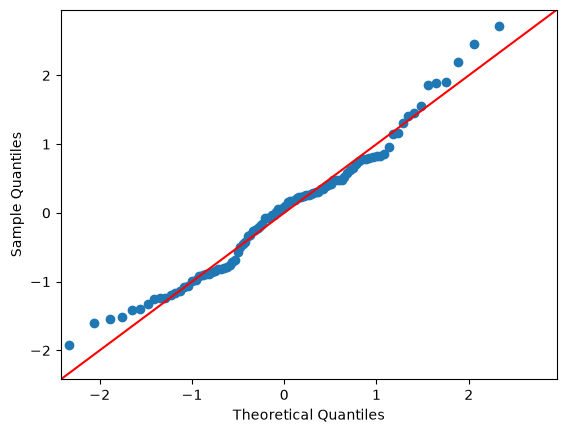

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

data_points = np.random.normal(0, 1, 100)    
sm.qqplot(data_points, line ='45')
plt.show()

In [14]:
df = pd.DataFrame(
    {
        'sample': np.random.normal(loc=10, scale=3, size=100),
    }
).sort_values('sample')
df['rank'] = df.index + 1  # 1-based indexing for the formula
df['p'] = (df['rank'] - 0.5) / n # Position-based cumulative probability (fractions from 0 to 1)
df['theory'] = stats.norm.ppf(df['p'])
df

,sample,rank,p,theory
46,1.909340,47,0.465,-0.087845
68,2.047091,69,0.685,0.481727
71,3.779829,72,0.715,0.568051
8,4.663839,9,0.085,-1.372204
30,4.922606,31,0.305,-0.510073
...,...,...,...,...
50,15.546868,51,0.505,0.012533
5,15.630387,6,0.055,-1.598193
22,15.646073,23,0.225,-0.755415
14,17.337256,15,0.145,-1.058122


<Axes: title={'center': 'Q-Q Plot From Scratch (Pandas)'}, xlabel='theory', ylabel='sample'>

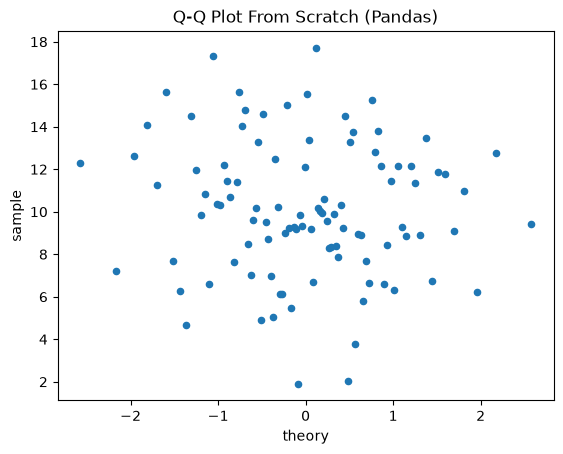

In [16]:
df.plot.scatter(
    x='theory', 
    y='sample', 
    title='Q-Q Plot From Scratch (Pandas)'
)


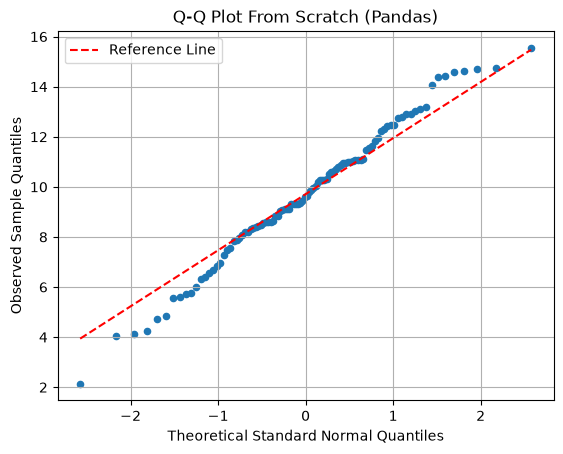

In [17]:
# 1. Generate or load a sample dataset into a Pandas DataFrame
np.random.seed(42)
raw_data = np.random.normal(loc=10, scale=3, size=100) # Mock normal data
df = pd.DataFrame({'sample_data': raw_data})

# 2. Sort the data in ascending order (Sample Quantiles)
df = df.sort_values(by='sample_data').reset_index(drop=True)

# 3. Calculate position-based cumulative probabilities (fractions from 0 to 1)
n = len(df)
df['rank_id'] = df.index + 1  # 1-based indexing for the formula
df['probability'] = (df['rank_id'] - 0.5) / n

# 4. Find theoretical quantiles using the standard normal inverse CDF (ppf)
df['theoretical_quantiles'] = stats.norm.ppf(df['probability'])

# 5. Create the Q-Q plot using Pandas
ax = df.plot.scatter(
    x='theoretical_quantiles', 
    y='sample_data', 
    grid=True, 
    title='Q-Q Plot From Scratch (Pandas)'
)

# 6. Add a reference line through the 1st and 3rd quartiles (robust to outliers)
# Calculate the slope and intercept based on the 25th and 75th percentiles
x1, x2 = stats.norm.ppf([0.25, 0.75])
y1, y2 = df['sample_data'].quantile([0.25, 0.75])
slope = (y2 - y1) / (x2 - x1)
intercept = y1 - slope * x1

# Plot the 45-degree reference trendline
x_vals = np.array([df['theoretical_quantiles'].min(), df['theoretical_quantiles'].max()])
y_vals = intercept + slope * x_vals
ax.plot(x_vals, y_vals, color='red', linestyle='--', label='Reference Line')

plt.ylabel('Observed Sample Quantiles')
plt.xlabel('Theoretical Standard Normal Quantiles')
plt.legend()
plt.show()


In [18]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def get_theoretical_quantiles(series: pd.Series, method: str = 'blom') -> pd.Series:
    """
    Transforms a pandas Series into its corresponding theoretical normal quantiles
    using a parameterized plotting position method.
    
    Parameters:
    -----------
    series : pd.Series
        The raw numeric feature.
    method : str, default 'blom'
        The plotting position method. Options: 'blom', 'gringorten', 'hazen', 'weibull'
        
    Returns:
    --------
    pd.Series
        Theoretical normal quantiles maintaining the original index alignment.
    """
    # 1. Define alpha based on the selected method
    methods = {
        'blom': 0.375,
        'gringorten': 0.44,
        'hazen': 0.5,
        'weibull': 0.0
    }
    
    chosen_method = method.lower()
    if chosen_method not in methods:
        raise ValueError(f"Method must be one of {list(methods.keys())}")
        
    alpha = methods[chosen_method]
    
    # 2. Get total number of valid elements (ignores NaNs if dropped)
    clean_series = series.dropna()
    n = len(clean_series)
    
    # 3. Calculate rank from 1 to n (maintains row mapping)
    ranks = clean_series.rank(method='first', ascending=True)
    
    # 4. Apply the generalized plotting position formula
    p_i = (ranks - alpha) / (n + 1 - (2 * alpha))
    
    # 5. Map the cumulative probabilities to standard normal Z-scores
    theoretical_values = stats.norm.ppf(p_i)
    
    # Return as a series mapped back to the original index
    return pd.Series(theoretical_values, index=clean_series.index)


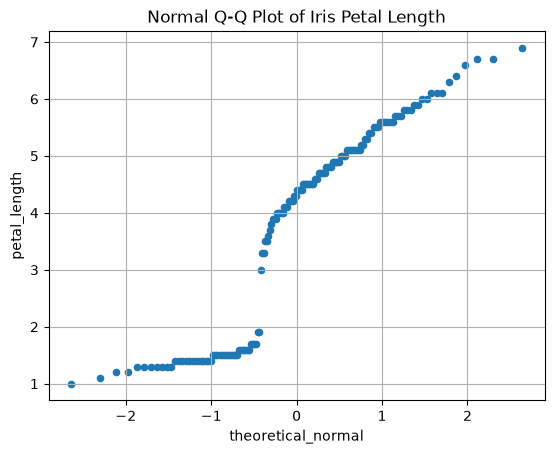

In [20]:
import seaborn as sns

# 1. Load the classic Iris dataset
iris = sns.load_dataset('iris')

# 2. Generate the theoretical quantiles using our function
iris['theoretical_normal'] = get_theoretical_quantiles(iris['petal_length'], method='blom')

# 3. Create the Q-Q Scatter Plot
iris.plot.scatter(
    x='theoretical_normal', 
    y='petal_length', 
    title='Normal Q-Q Plot of Iris Petal Length',
    grid=True
)
plt.show()
